<a href="https://colab.research.google.com/github/Amper2B/GVC_MiniCaseStudy/blob/main/FusionModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from torchvision import transforms, models
import torch.nn as nn

In [ ]:

from google.colab import files
uploaded = files.upload()

Saving coconuts.jpeg to coconuts.jpeg
Saving eyes.jpg to eyes.jpg
Saving corns.jpg to corns.jpg
Saving dog.jpg to dog.jpg
Saving monument.jpg to monument.jpg
Saving icedtea.jpg to icedtea.jpg
Saving car.jpg to car.jpg
Saving Chameleon.jpg to Chameleon.jpg
Saving boyfigurine.jpg to boyfigurine.jpg
Saving Penguin.jpeg to Penguin.jpeg


Select your 10 different images from your phone gallery/files.


Saving coconuts.jpeg to coconuts (1).jpeg
Saving eyes.jpg to eyes (1).jpg
Saving dog.jpg to dog (1).jpg
Saving corns.jpg to corns (1).jpg
Saving monument.jpg to monument (1).jpg
Saving icedtea.jpg to icedtea (1).jpg
Saving car.jpg to car (1).jpg
Saving Chameleon.jpg to Chameleon (1).jpg
Saving boyfigurine.jpg to boyfigurine (1).jpg
Saving Penguin.jpeg to Penguin (1).jpeg
✅ Successfully moved coconuts (1).jpeg to dataset/coconut/
✅ Successfully moved eyes (1).jpg to dataset/eyes/
✅ Successfully moved dog (1).jpg to dataset/dog/
✅ Successfully moved corns (1).jpg to dataset/corns/
✅ Successfully moved monument (1).jpg to dataset/monument/
✅ Successfully moved icedtea (1).jpg to dataset/icedtea/
✅ Successfully moved car (1).jpg to dataset/car/
✅ Successfully moved Chameleon (1).jpg to dataset/chameleon/
✅ Successfully moved boyfigurine (1).jpg to dataset/boyfigurine/
✅ Successfully moved Penguin (1).jpeg to dataset/penguin/
Downloading: "https://download.pytorch.org/models/resnet18-f37072

100%|██████████| 44.7M/44.7M [00:00<00:00, 108MB/s]


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 62.3MB/s]



Starting Training...
Epoch 1/15 - Loss: 3.2269
Epoch 2/15 - Loss: 1.8846
Epoch 3/15 - Loss: 1.4930
Epoch 4/15 - Loss: 1.6782
Epoch 5/15 - Loss: 0.6482
Epoch 6/15 - Loss: 0.5467
Epoch 7/15 - Loss: 0.3345
Epoch 8/15 - Loss: 0.4948
Epoch 9/15 - Loss: 0.2492
Epoch 10/15 - Loss: 0.1544
Epoch 11/15 - Loss: 0.2612
Epoch 12/15 - Loss: 0.0817
Epoch 13/15 - Loss: 0.1628
Epoch 14/15 - Loss: 0.0814
Epoch 15/15 - Loss: 0.1408


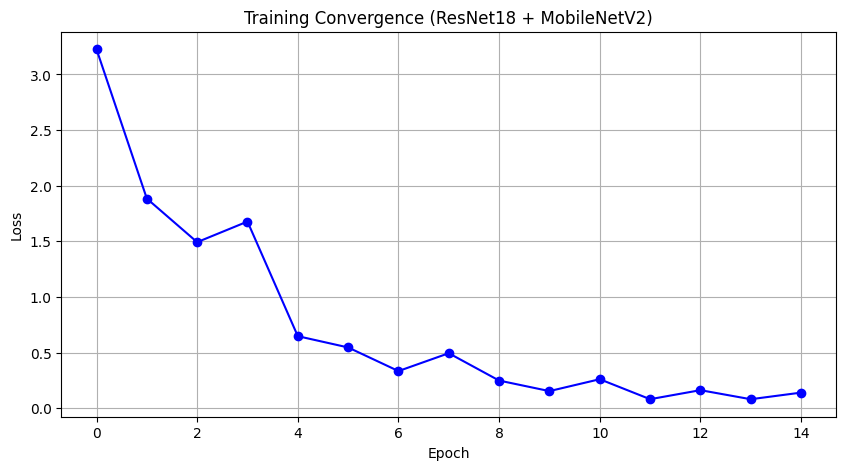


--- Final Prediction Check ---
Actual: boyfigurine | Predicted: boyfigurine
Actual: chameleon | Predicted: chameleon


In [ ]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from torchvision import transforms, models
import torch.nn as nn
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# Updated list (Removed "ball")
object_names = ["car", "icedtea", "dog", "eyes", "monument",
                "penguin", "corns", "coconut", "chameleon", "boyfigurine"]

# Create folders
for name in object_names:
    os.makedirs(f'dataset/{name}', exist_ok=True)

print("Select your 10 different images from your phone gallery/files.")
uploaded = files.upload()

for filename in uploaded.keys():
    moved = False
    for name in object_names:
        # Matches filename to folder (e.g., "my_car.jpg" goes to "car" folder)
        if name in filename.lower():
            os.replace(filename, f'dataset/{name}/{filename}')
            print(f"✅ Successfully moved {filename} to dataset/{name}/")
            moved = True
            break
    if not moved:
        print(f"⚠️ Warning: {filename} did not match any category names. It stayed in the main folder.")
# It remains in the main directory if no name match was found.
        print(f"⚠️ {filename} stayed in main directory. Move it manually if needed.")

# 1. Prepare Data Loader
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

dataset = ImageFolder('dataset', transform=transform)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

# 2. Define Fusion Architecture
class FusionModel(nn.Module):
    def __init__(self, num_classes=10):
        super(FusionModel, self).__init__()
        self.resnet = models.resnet18(weights='DEFAULT')
        self.mobile = models.mobilenet_v2(weights='DEFAULT')

        # Strip classification heads
        self.resnet.fc = nn.Identity()
        self.mobile.classifier = nn.Identity()

        # Combine: ResNet(512) + MobileNet(1280) = 1792
        self.classifier = nn.Linear(1792, num_classes)

    def forward(self, x):
        f1 = self.resnet(x)
        f2 = self.mobile(x)
        combined = torch.cat((f1, f2), dim=1)
        return self.classifier(combined)

model = FusionModel(num_classes=len(object_names))

# 3. Training Loop
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

losses = []
print("\nStarting Training...")
for epoch in range(15):
    epoch_loss = 0
    for images, labels in loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/15 - Loss: {avg_loss:.4f}")

# 4. Results Visualization
plt.figure(figsize=(10, 5))
plt.plot(losses, marker='o', color='b')
plt.title("Training Convergence (ResNet18 + MobileNetV2)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# 5. Final Prediction Test
print("\n--- Final Prediction Check ---")
model.eval()
for images, labels in loader:
    with torch.no_grad():
        output = model(images)
        _, pred = torch.max(output, 1)
        for i in range(len(images)):
            actual = dataset.classes[labels[i]]
            predicted = dataset.classes[pred[i]]
            print(f"Actual: {actual} | Predicted: {predicted}")
    break # Test first batch only

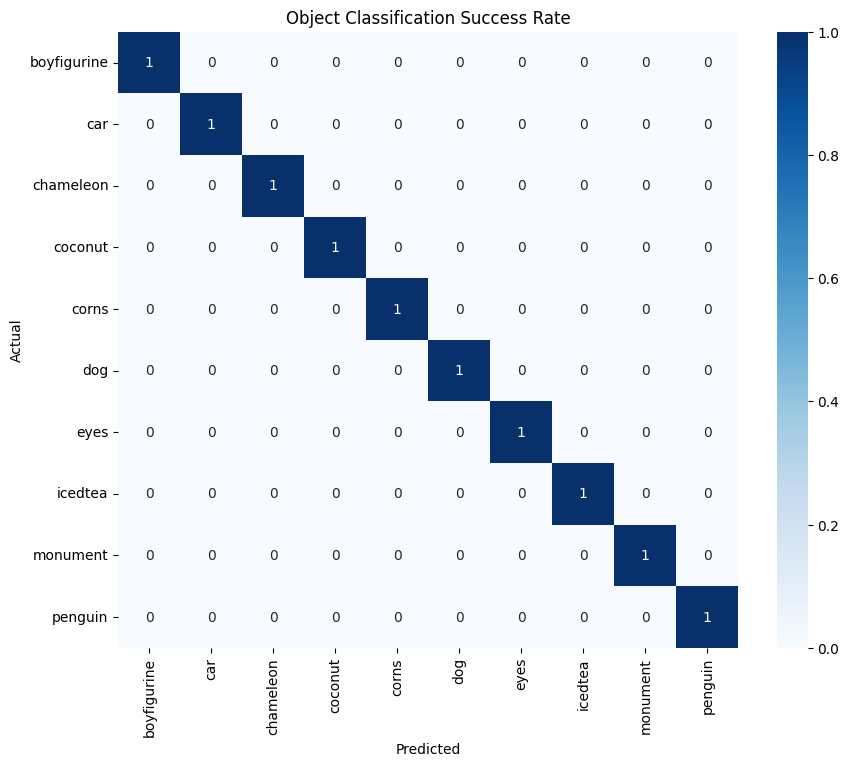

              precision    recall  f1-score   support

 boyfigurine       1.00      1.00      1.00         1
         car       1.00      1.00      1.00         1
   chameleon       1.00      1.00      1.00         1
     coconut       1.00      1.00      1.00         1
       corns       1.00      1.00      1.00         1
         dog       1.00      1.00      1.00         1
        eyes       1.00      1.00      1.00         1
     icedtea       1.00      1.00      1.00         1
    monument       1.00      1.00      1.00         1
     penguin       1.00      1.00      1.00         1

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Generate Confusion Matrix
all_preds = []
all_labels = []
model.eval()

with torch.no_grad():
    for images, labels in loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

# Create Heatmap
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, xticklabels=dataset.classes, yticklabels=dataset.classes, cmap='Blues')
plt.title('Object Classification Success Rate')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Print Objective Report
print(classification_report(all_labels, all_preds, target_names=dataset.classes))

In [ ]:

# Initialize Baseline (ResNet18 only)
baseline_model = models.resnet18(weights='DEFAULT')
baseline_model.fc = nn.Linear(512, len(object_names))

# Training Setup
b_criterion = nn.CrossEntropyLoss()
b_optimizer = torch.optim.Adam(baseline_model.parameters(), lr=0.001)

print("Training Baseline (ResNet18)...")
for epoch in range(15):
    for images, labels in loader:
        b_optimizer.zero_grad()
        outputs = baseline_model(images)
        loss = b_criterion(outputs, labels)
        loss.backward()
        b_optimizer.step()
print("Baseline Training Complete.")

Training Baseline (ResNet18)...
Baseline Training Complete.


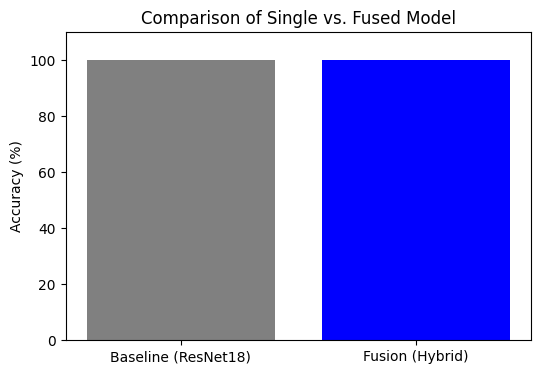

Baseline Accuracy: 100.0%
Fusion Accuracy: 100.0%
Improvement: 0.0%


In [ ]:

def get_acc(m):
    m.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            outputs = m(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return (correct / total) * 100

# Get both scores
base_acc = get_acc(baseline_model)
fusion_acc = get_acc(model) # Your already trained Fusion model

# Plot results
plt.figure(figsize=(6, 4))
plt.bar(['Baseline (ResNet18)', 'Fusion (Hybrid)'], [base_acc, fusion_acc], color=['gray', 'blue'])
plt.ylabel('Accuracy (%)')
plt.title('Comparison of Single vs. Fused Model')
plt.ylim(0, 110)
plt.show()

print(f"Baseline Accuracy: {base_acc}%")
print(f"Fusion Accuracy: {fusion_acc}%")
print(f"Improvement: {fusion_acc - base_acc}%")